In [63]:
# Imports PyTorch, torchvision, NumPy, and Matplotlib for model building, data handling, and visualization. 
# Each library provides essential tools for deep learning and plotting.

import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
import numpy as np
import os
from PIL import Image

import matplotlib.pyplot as plt
%matplotlib inline

In [64]:
# loading in all images from the folder

# Folder containing the .jpg files
image_dir = "images"

# Lists for image tensors and labels
images = []
labels = []

# Loop through the directory
for filename in os.listdir(image_dir):
    if filename.lower().endswith(".jpg"):
        path = os.path.join(image_dir, filename)

        # Open and convert to RGB just in case
        img = Image.open(path).convert("RGB")

        # Resize to a consistent shape for the CNN
        img = img.resize((224, 224))

        # Convert to NumPy array and normalize
        img_array = np.array(img, dtype="float32") / 255.0

        images.append(img_array)

        # Label generation based on the file name
        if filename.startswith("razorback"):
            labels.append(1)      # positive class
        else:
            labels.append(0)      # negative class

# Convert to arrays
X = np.stack(images)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Label counts -> Razorback:", np.sum(y==1),
      ", Not:", np.sum(y==0))

X shape: (50, 224, 224, 3)
y shape: (50,)
Label counts -> Razorback: 10 , Not: 40


In [65]:
# Train-test Split

from sklearn.model_selection import train_test_split

# Perform train/test split (80% train, 20% test)
# Stratify keeps the razorback/not class balance similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40, 224, 224, 3)
y_train shape: (40,)
X_test shape: (10, 224, 224, 3)
y_test shape: (10,)


In [66]:
# Creating a Custom Dataset Class

import torch
from torch.utils.data import Dataset

class RazorbackDataset(Dataset):
    def __init__(self, X, y):
        # Convert numpy arrays to float tensors for CNN input
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2)
        # Convert labels to int64 tensors for loss functions like CrossEntropy
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [67]:
# Creating training and validation datasets

train_dataset = RazorbackDataset(X_train, y_train)
valid_dataset = RazorbackDataset(X_test, y_test)

In [68]:
# Creating DataLoaders

from torch.utils.data import DataLoader

batch_size = 16   # smaller dataset means a smaller batch size

torch.manual_seed(1)

train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dl = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_dl))
print("Valid batches:", len(valid_dl))

Train batches: 3
Valid batches: 1


In [69]:
import torch
import torch.nn as nn

model = nn.Sequential()

# First conv layer now expects 3-channel RGB images
model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=32, kernel_size=5, padding=2))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(kernel_size=2))

# Second conv layer
model.add_module('conv2', nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2))
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(kernel_size=2))

# After two 2×2 poolings, 224 → 112 → 56
# So feature map size = (64, 56, 56)
model.add_module('flatten', nn.Flatten())

# Fully connected classifier — adding a simple head for binary classification
model.add_module('fc1', nn.Linear(64 * 56 * 56, 128))
model.add_module('relu3', nn.ReLU())
model.add_module('fc2', nn.Linear(128, 2))   # 2 classes: razorback vs not

In [70]:
# sample batch of RGB images
x = torch.ones((4, 3, 224, 224))

model(x).shape

torch.Size([4, 2])

In [71]:
# 64 * 56 * 56 = 200704
model.add_module('fc1', nn.Linear(200704, 1024))
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(p=0.5))

# Two output classes for binary classification
model.add_module('fc2', nn.Linear(1024, 2))

In [72]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

In [73]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [74]:
def train(model, num_epochs, train_dl, valid_dl):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item()*y_batch.size(0)
            is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.sum().cpu()

        loss_hist_train[epoch] /= len(train_dl.dataset)
        accuracy_hist_train[epoch] /= len(train_dl.dataset)

        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in valid_dl:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                pred = model(x_batch)
                loss = loss_fn(pred, y_batch)
                loss_hist_valid[epoch] += loss.item()*y_batch.size(0)
                is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
                accuracy_hist_valid[epoch] += is_correct.sum().cpu()

        loss_hist_valid[epoch] /= len(valid_dl.dataset)
        accuracy_hist_valid[epoch] /= len(valid_dl.dataset)

        print(f'Epoch {epoch+1} accuracy: {accuracy_hist_train[epoch]:.4f} val_accuracy: {accuracy_hist_valid[epoch]:.4f}')
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

In [75]:
torch.manual_seed(1)
num_epochs = 50
hist = train(model, num_epochs, train_dl, valid_dl)

Epoch 1 accuracy: 0.6000 val_accuracy: 0.8000
Epoch 2 accuracy: 0.8000 val_accuracy: 0.8000
Epoch 3 accuracy: 0.8250 val_accuracy: 0.8000
Epoch 4 accuracy: 0.7500 val_accuracy: 0.8000
Epoch 5 accuracy: 0.8000 val_accuracy: 0.8000
Epoch 6 accuracy: 0.8000 val_accuracy: 0.8000
Epoch 7 accuracy: 0.7750 val_accuracy: 0.8000
Epoch 8 accuracy: 0.8250 val_accuracy: 0.8000
Epoch 9 accuracy: 0.8250 val_accuracy: 0.8000
Epoch 10 accuracy: 0.8500 val_accuracy: 0.9000
Epoch 11 accuracy: 0.9000 val_accuracy: 0.8000
Epoch 12 accuracy: 0.8500 val_accuracy: 0.9000
Epoch 13 accuracy: 0.8500 val_accuracy: 0.8000
Epoch 14 accuracy: 0.9000 val_accuracy: 0.9000
Epoch 15 accuracy: 0.8500 val_accuracy: 0.9000
Epoch 16 accuracy: 0.9500 val_accuracy: 0.9000
Epoch 17 accuracy: 0.9250 val_accuracy: 0.9000
Epoch 18 accuracy: 0.9250 val_accuracy: 0.9000
Epoch 19 accuracy: 0.9250 val_accuracy: 0.8000
Epoch 20 accuracy: 0.9750 val_accuracy: 0.8000
Epoch 21 accuracy: 0.9000 val_accuracy: 0.9000
Epoch 22 accuracy: 0.9

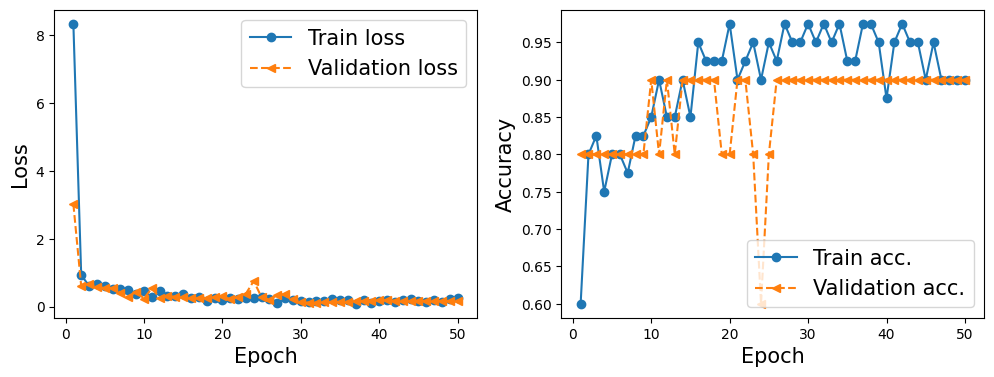

In [76]:
import numpy as np
import matplotlib.pyplot as plt

x_arr = np.arange(len(hist[0])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist[0], '-o', label='Train loss')
ax.plot(x_arr, hist[1], '--<', label='Validation loss')
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Loss', size=15)
ax.legend(fontsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist[2], '-o', label='Train acc.')
ax.plot(x_arr, hist[3], '--<', label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)

#plt.savefig('figures/14_13.png')
plt.show()

In [77]:
# Final evaluation on the validation set for the razorback vs not model

model.eval()

# Make sure model is on the same device as the data
model.to(device)

if device.type == 'cuda':
    torch.cuda.synchronize()

correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in valid_dl:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(x_batch)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

test_accuracy = correct / total
print(f'Test accuracy: {test_accuracy:.4f}')

Test accuracy: 0.9000


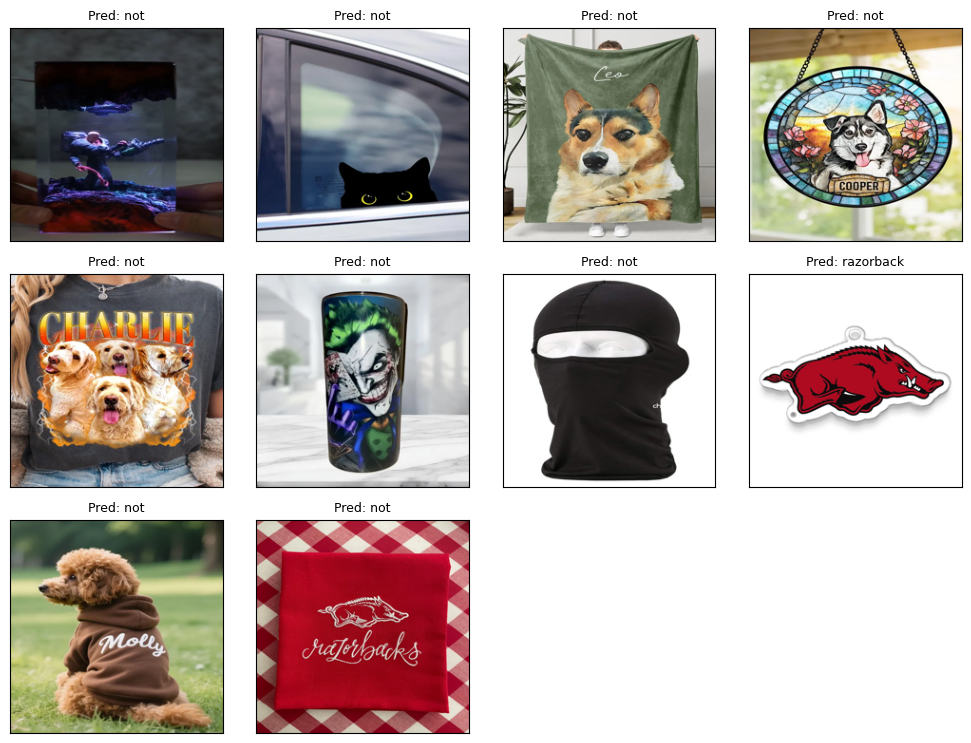

In [78]:
# Visualizing model predictions on up to 16 validation images

model.eval()

# Grab one batch from the validation loader
x_batch, y_batch = next(iter(valid_dl))

# Move inputs to the same device as the model
x_batch = x_batch.to(device)

with torch.no_grad():
    outputs = model(x_batch)
    preds = torch.argmax(outputs, dim=1).cpu()

# Move images back to CPU for plotting
x_batch_cpu = x_batch.cpu()

class_names = ['not', 'razorback']  # 0 -> not, 1 -> razorback

fig = plt.figure(figsize=(10, 10))
num_images = min(16, x_batch_cpu.size(0))

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1)
    ax.set_xticks([])
    ax.set_yticks([])

    # Convert from (C, H, W) to (H, W, C)
    img = x_batch_cpu[i].permute(1, 2, 0).numpy()

    ax.imshow(img)
    ax.set_title(
        f"Pred: {class_names[preds[i].item()]}",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [79]:
# Processing the validation_images folder

val_dir = "validation_images"

val_images = []
val_labels = []
val_filenames = []   # keep track of filenames for inspection

for filename in os.listdir(val_dir):
    if filename.lower().endswith(".jpg"):
        path = os.path.join(val_dir, filename)

        # Open and standardize to RGB
        img = Image.open(path).convert("RGB")

        # Resize to match the training size
        img = img.resize((224, 224))

        # Convert to NumPy and normalize to [0, 1]
        img_array = np.array(img, dtype="float32") / 255.0

        val_images.append(img_array)
        val_filenames.append(filename)

        # Label based on file name prefix
        if filename.startswith("razorback"):
            val_labels.append(1)
        else:
            val_labels.append(0)

# Convert to arrays
X_val = np.stack(val_images)
y_val = np.array(val_labels)

print("Validation X shape:", X_val.shape)
print("Validation y shape:", y_val.shape)
print("Label counts -> Razorback:", np.sum(y_val == 1),
      ", Not:", np.sum(y_val == 0))

Validation X shape: (16, 224, 224, 3)
Validation y shape: (16,)
Label counts -> Razorback: 4 , Not: 12


In [80]:
# Create a Dataset and DataLoader for validation_images

val_dataset = RazorbackDataset(X_val, y_val)

val_batch_size = 16
val_dl = DataLoader(val_dataset, batch_size=val_batch_size, shuffle=False)

print("Validation_images batches:", len(val_dl))

Validation_images batches: 1


In [81]:
# Run the trained model on validation_images and compute accuracy

model.eval()
model.to(device)

correct = 0
total = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for x_batch, y_batch in val_dl:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(x_batch)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

val_accuracy = correct / total
print(f"Validation_images accuracy: {val_accuracy:.4f}")

Validation_images accuracy: 0.7500


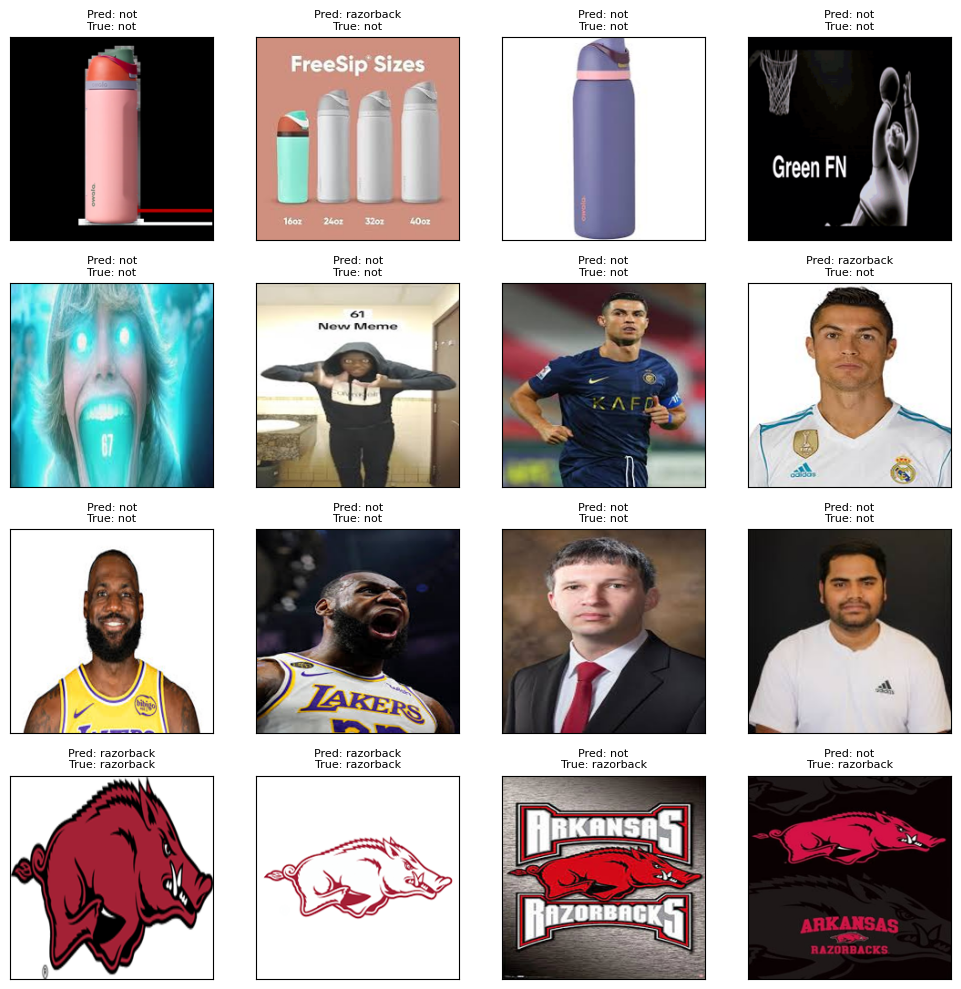

In [82]:
import matplotlib.pyplot as plt
import torch

# Make sure model is in eval mode and on the correct device
model.eval()
model.to(device)

# Grab one batch from the new validation_images DataLoader
x_batch, y_batch = next(iter(val_dl))

# Move to device
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    outputs = model(x_batch)
    preds = torch.argmax(outputs, dim=1).cpu()

# Move images back to CPU for plotting
x_batch_cpu = x_batch.cpu()
y_batch_cpu = y_batch.cpu()

class_names = ['not', 'razorback']

fig = plt.figure(figsize=(10, 10))
num_images = min(16, x_batch_cpu.size(0))

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1)
    ax.set_xticks([])
    ax.set_yticks([])

    # Convert CHW → HWC for display
    img = x_batch_cpu[i].permute(1, 2, 0).numpy()

    ax.imshow(img)
    ax.set_title(
        f"Pred: {class_names[preds[i]]}\nTrue: {class_names[y_batch_cpu[i]]}",
        fontsize=8
    )

plt.tight_layout()
plt.show()

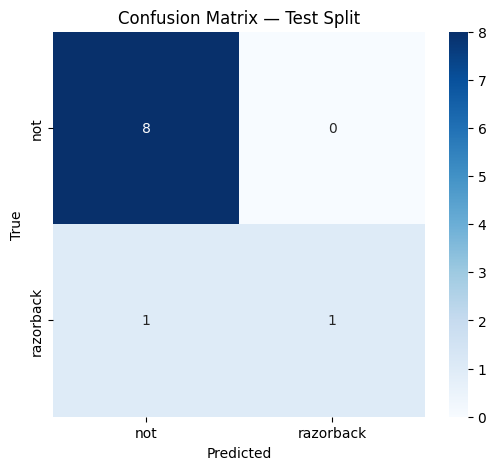

In [84]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# Collect all predictions + labels
all_preds = []
all_labels = []

model.eval()
model.to(device)

with torch.no_grad():
    for x_batch, y_batch in valid_dl:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(x_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Build confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = ['not', 'razorback']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Test Split")
plt.show()

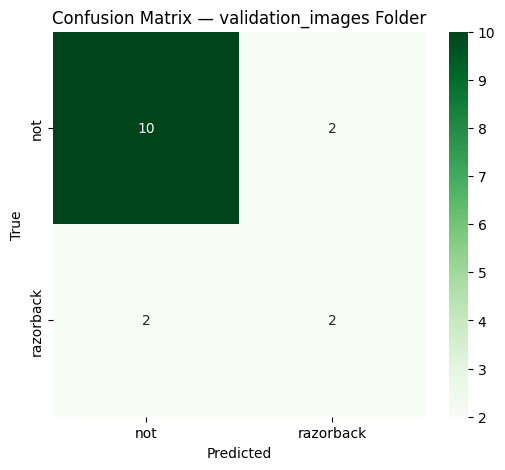

In [85]:
# Collect predictions for validation_images folder
val_preds = []
val_labels_true = []

model.eval()
model.to(device)

with torch.no_grad():
    for x_batch, y_batch in val_dl:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(x_batch)
        preds = torch.argmax(outputs, dim=1)

        val_preds.extend(preds.cpu().numpy())
        val_labels_true.extend(y_batch.cpu().numpy())

# Confusion matrix
cm_val = confusion_matrix(val_labels_true, val_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — validation_images Folder")
plt.show()